<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/main/California_housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ECE 601: Linear Regression with California Housing Dataset**

# Problem 1: Implement both standard and stochastic gradient descent as done. Use 1000 iterations for batch gradient descent and 100 epochs for stochastic gradient descent and set the step size to 10^-4.
Our goal is to set up a regression model where the median house value is predicted from the other numerical variables in the dataset.

# 1. Import Libraries and Load Data
 We start by collecting the data and showing the first few rows.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True).frame.copy()

print("Dataset shape:", housing.shape)
housing.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#2. Data Exploration and Preprocessing

Remover samples where y > 5 and check missing values (should be none)

In [12]:
print("\nMissing values:\n", housing.isnull().sum())

# Remove samples where y > 5
housing = housing[housing["MedHouseVal"] <= 5].copy()
print("\nCleaned dataset shape:", housing.shape)

print("\nDataset statistics:")
print(housing.describe())


Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Cleaned dataset shape: (19675, 9)

Dataset statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  19675.000000  19675.000000  19675.000000  19675.000000  19675.000000   
mean       3.676717     28.386277      5.360901      1.096618   1440.812198   
std        1.570272     12.509113      2.292538      0.451839   1143.648725   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.526800     18.000000      4.414568      1.005894    796.000000   
50%        3.450000     28.000000      5.184322      1.048622   1179.000000   
75%        4.582600     37.000000      5.970677      1.099338   1746.000000   
max       15.000100     52.000000    132.533333     34.066667  35682.000000   

           AveOccup      Latitude     Longitude 

Next, we check the correlation among the features to preview which features may be most helpful in prediction.

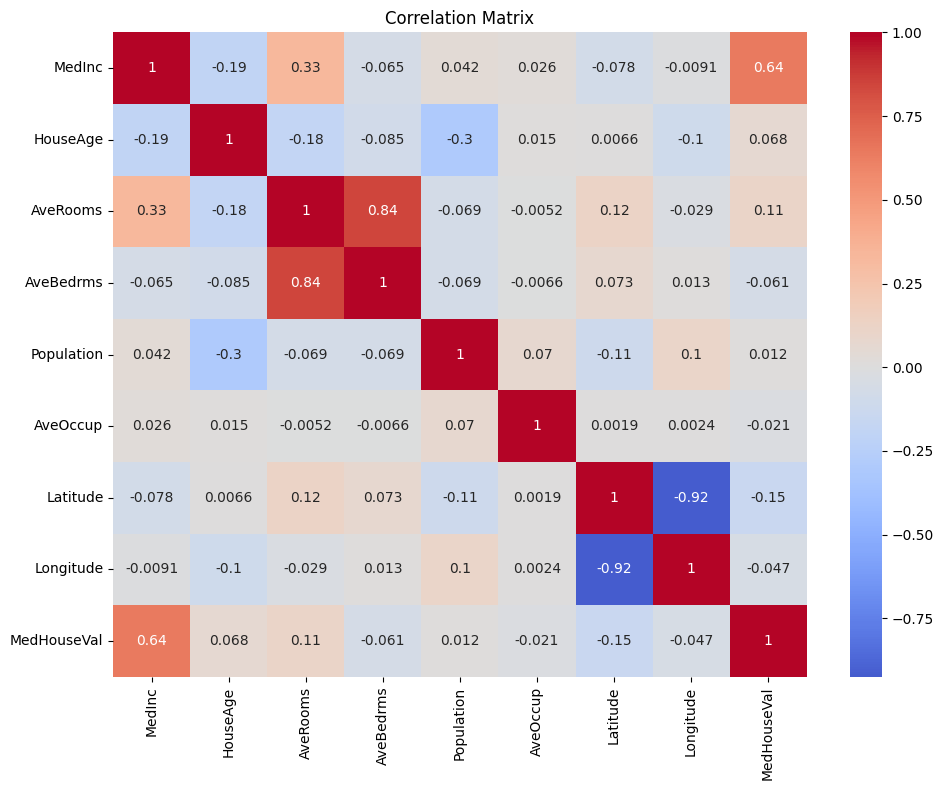

In [13]:
# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 3. Prepare Data for Regression
Some common steps for prediction can be done optionally: normalization/centering (remove mean, normalize by variance, to obtain variables following standard Gaussian distribution). We also add a 1 at the end of each sample to allow for an offset/bias ( 𝜃0 ).

In [14]:
X = housing[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']].values
y = housing['MedHouseVal'].values.reshape(-1, 1)

# Standardize features (mean=0, std=1)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

# Add bias term (column of ones)
X_with_bias = np.c_[np.ones((X.shape[0], 1)), X]
X_normalized_with_bias = np.c_[np.ones((X_normalized.shape[0], 1)), X_normalized]

# Normalize target for better convergence
y_mean = y.mean()
y_std = y.std()
y_normalized = (y - y_mean) / y_std

print("Feature matrix shape (with bias):", X_with_bias.shape)
print("Target vector shape:", y_normalized.shape)

Feature matrix shape (with bias): (19675, 9)
Target vector shape: (19675, 1)


# 4. Implement Ordinary Least Squares Loss and Gradient


In [15]:
def compute_loss(X, y, theta):
    """
    Compute the ordinary least squares (OLS) loss.
    Loss = (1/2m) * sum((y_pred - y)^2)
    """
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    loss = (1 / (2 * m)) * np.sum(errors ** 2)
    return loss

def compute_gradient(X, y, theta):
    """
    Compute the gradient of the OLS loss.
    Gradient = (1/m) * X.T @ (X @ theta - y)
    """
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    gradient = (1 / m) * (X.T @ errors)
    return gradient

# 5. Standard Gradient Descent (Batch GD)
One more function to define: gradient descent, which uses compute_gradient.

In [16]:
def gradient_descent(X, y, learning_rate=0.0001, n_iterations=1000):
    """
    Perform standard (batch) gradient descent.
    Uses the entire dataset to compute the gradient at each iteration.
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for i in range(n_iterations):
        gradient = compute_gradient(X, y, theta)

        theta = theta - learning_rate * gradient

        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

We now run GD with the origina data and the normalized/centered data.

In [17]:
# Run standard gradient descent
print("Running Standard Gradient Descent with original data...")
theta_orig_gd, loss_history_orig_gd = gradient_descent(X_with_bias, y, learning_rate=0.0001, n_iterations=1000)

print(f"Bias: {theta_orig_gd[0, 0]:.4f}")
print(f"\nFinal Loss (GD): {loss_history_orig_gd[-1]:.6f}")

Running Standard Gradient Descent with original data...
Bias: nan

Final Loss (GD): nan


/tmp/ipython-input-251/3074507971.py:9: RuntimeWarning: overflow encountered in square
  loss = (1 / (2 * m)) * np.sum(errors ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-251/3074507971.py:20: RuntimeWarning: overflow encountered in matmul
  gradient = (1 / m) * (X.T @ errors)
/tmp/ipython-input-251/1037742449.py:13: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient


In [18]:
# Run standard gradient descent
print("Running Standard Gradient Descent with centered data...")
theta_center_gd, loss_history_center_gd = gradient_descent(X_normalized_with_bias, y_normalized, learning_rate=0.0001, n_iterations=1000)

print("\nFinal parameters (GD):")
print(f"Bias: {theta_center_gd[0, 0]:.4f}")
print(f"MedInc: {theta_center_gd[1, 0]:.4f}")
print(f"HouseAge: {theta_center_gd[2, 0]:.4f}")
print(f"AveRooms: {theta_center_gd[3, 0]:.4f}")
print(f"AveBedrms: {theta_center_gd[4, 0]:.4f}")
print(f"Population: {theta_center_gd[5, 0]:.4f}")
print(f"AveOccup: {theta_center_gd[6, 0]:.4f}")
print(f"Latitude: {theta_center_gd[7, 0]:.4f}")
print(f"Longitude: {theta_center_gd[8, 0]:.4f}")

print(f"\nFinal Loss (GD): {loss_history_center_gd[-1]:.6f}")

Running Standard Gradient Descent with centered data...

Final parameters (GD):
Bias: 0.0000
MedInc: 0.0610
HouseAge: 0.0071
AveRooms: 0.0098
AveBedrms: -0.0059
Population: 0.0011
AveOccup: -0.0021
Latitude: -0.0141
Longitude: -0.0050

Final Loss (GD): 0.458635


# 6. Stochastic Gradient Descent (SGD)
Next, we define a function for SGD, and again run it for original and centered data.

In [19]:
def stochastic_gradient_descent(X, y, learning_rate=0.0001, n_epochs=100, random_seed=42):
    """
    Perform stochastic gradient descent.
    Updates parameters using one sample at a time.
    """
    np.random.seed(random_seed)
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)

        for i in indices:
            xi = X[i:i+1, :]
            yi = y[i:i+1, :]

            prediction = xi @ theta
            error = prediction - yi
            gradient = xi.T @ error

            theta = theta - learning_rate * gradient

        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

In [20]:
# Run stochastic gradient descent
print("Running Stochastic Gradient Descent with original data...")
theta_orig_sgd, loss_history_orig_sgd = stochastic_gradient_descent(X_with_bias, y, learning_rate=0.0001, n_epochs=100)

print(f"Bias: {theta_orig_sgd[0, 0]:.4f}")
print(f"\nFinal Loss (SGD): {loss_history_orig_sgd[-1]:.6f}")

Running Stochastic Gradient Descent with original data...


/tmp/ipython-input-251/96263973.py:20: RuntimeWarning: overflow encountered in matmul
  gradient = xi.T @ error
/tmp/ipython-input-251/96263973.py:22: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient


Bias: nan

Final Loss (SGD): nan


In [21]:
# Run stochastic gradient descent
print("Running Stochastic Gradient Descent with centered data...")
theta_center_sgd, loss_history_center_sgd = stochastic_gradient_descent(X_normalized_with_bias, y_normalized, learning_rate=0.0001, n_epochs=100)

#print("\nFinal parameters (SGD):")
print(f"Bias: {theta_center_sgd[0, 0]:.4f}")
print(f"MedInc: {theta_center_sgd[1, 0]:.4f}")
print(f"HouseAge: {theta_center_sgd[2, 0]:.4f}")
print(f"AveRooms: {theta_center_sgd[3, 0]:.4f}")
print(f"AveBedrms: {theta_center_sgd[4, 0]:.4f}")
print(f"Population: {theta_center_sgd[5, 0]:.4f}")
print(f"AveOccup: {theta_center_sgd[6, 0]:.4f}")
print(f"Latitude: {theta_center_sgd[7, 0]:.4f}")
print(f"Longitude: {theta_center_sgd[8, 0]:.4f}")
print(f"\nFinal Loss (SGD): {loss_history_center_sgd[-1]:.6f}")

Running Stochastic Gradient Descent with centered data...
Bias: -0.0001
MedInc: 0.6903
HouseAge: 0.1061
AveRooms: -0.2826
AveBedrms: 0.2452
Population: 0.0072
AveOccup: -0.0429
Latitude: -0.8384
Longitude: -0.8114

Final Loss (SGD): 0.216813


# 7. Compare Results
The following plots show the evolution of the losss function in each of the cases we ran.

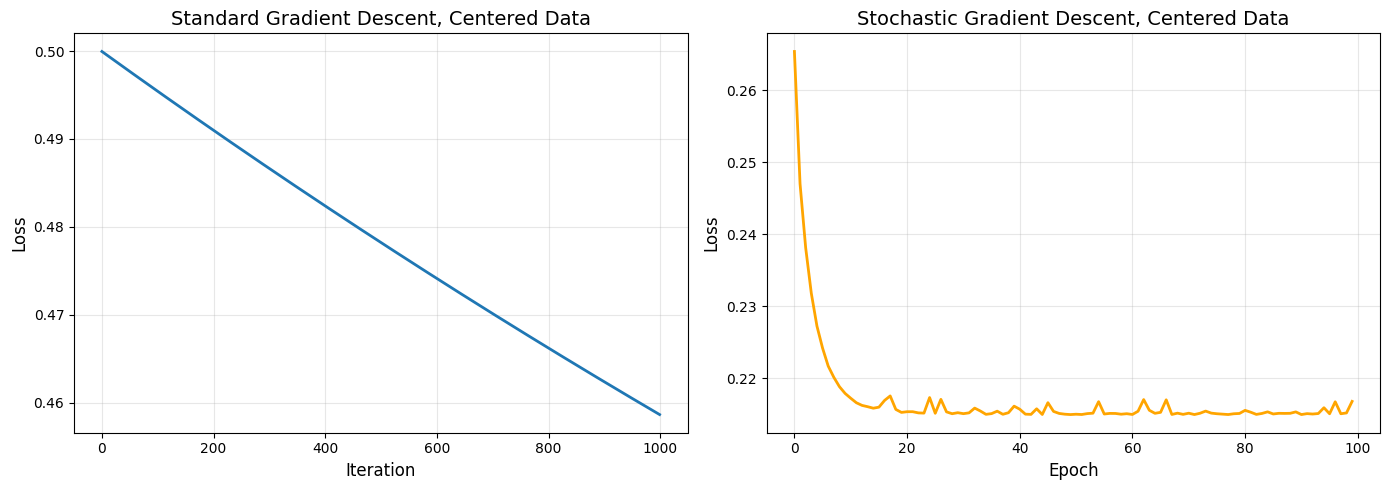

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history_center_gd, linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Standard Gradient Descent, Centered Data', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history_center_sgd, linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Stochastic Gradient Descent, Centered Data', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
comparison_center_df = pd.DataFrame({
    'Parameter': ['Bias', 'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'],
    'Standard GD': theta_center_gd.flatten(),
    'Stochastic GD': theta_center_sgd.flatten(),
    'Difference': np.abs(theta_center_gd.flatten() - theta_center_sgd.flatten())
})

print("Parameter Comparison (Centered Data):")
print(comparison_center_df.to_string(index=False))

Parameter Comparison (Centered Data):
 Parameter   Standard GD  Stochastic GD  Difference
      Bias  6.687239e-18      -0.000061    0.000061
    MedInc  6.098592e-02       0.690268    0.629282
  HouseAge  7.112754e-03       0.106077    0.098964
  AveRooms  9.846070e-03      -0.282641    0.292487
 AveBedrms -5.946092e-03       0.245221    0.251168
Population  1.078053e-03       0.007228    0.006150
  AveOccup -2.127475e-03      -0.042899    0.040771
  Latitude -1.413147e-02      -0.838378    0.824246
 Longitude -5.006426e-03      -0.811379    0.806372


# 8. Model Evaluation
To evaluate the four models, we compute the average error of the predictions.

In [24]:
y_pred_center_gd = X_normalized_with_bias @ theta_center_gd
y_pred_center_sgd = X_normalized_with_bias @ theta_center_sgd

y_pred_gd_decentered = y_pred_center_gd * y_std + y_mean
y_pred_sgd_decentered = y_pred_center_sgd * y_std + y_mean
y_actual = y

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_center_gd = r_squared(y_actual, y_pred_gd_decentered)
r2_center_sgd = r_squared(y_actual, y_pred_sgd_decentered)

print(f"R² Score (Standard GD Centered Data): {r2_center_gd:.4f}")
print(f"R² Score (Stochastic GD Centered Data): {r2_center_sgd:.4f}")

# RMSE
rmse_gd_center = np.sqrt(np.mean((y_actual - y_pred_gd_decentered) ** 2))
rmse_sgd_center = np.sqrt(np.mean((y_actual - y_pred_sgd_decentered) ** 2))

print(f"\nRMSE (Standard GD Centered Data): {rmse_gd_center * 100000:.2f} in target units")
print(f"RMSE (Stochastic GD Centered Data): {rmse_sgd_center * 100000:.2f} in target units")

R² Score (Standard GD Centered Data): 0.0827
R² Score (Stochastic GD Centered Data): 0.5664

RMSE (Standard GD Centered Data): 93580.06 in target units
RMSE (Stochastic GD Centered Data): 64341.64 in target units


We also visualize the predictions vs. errors as point clouds.

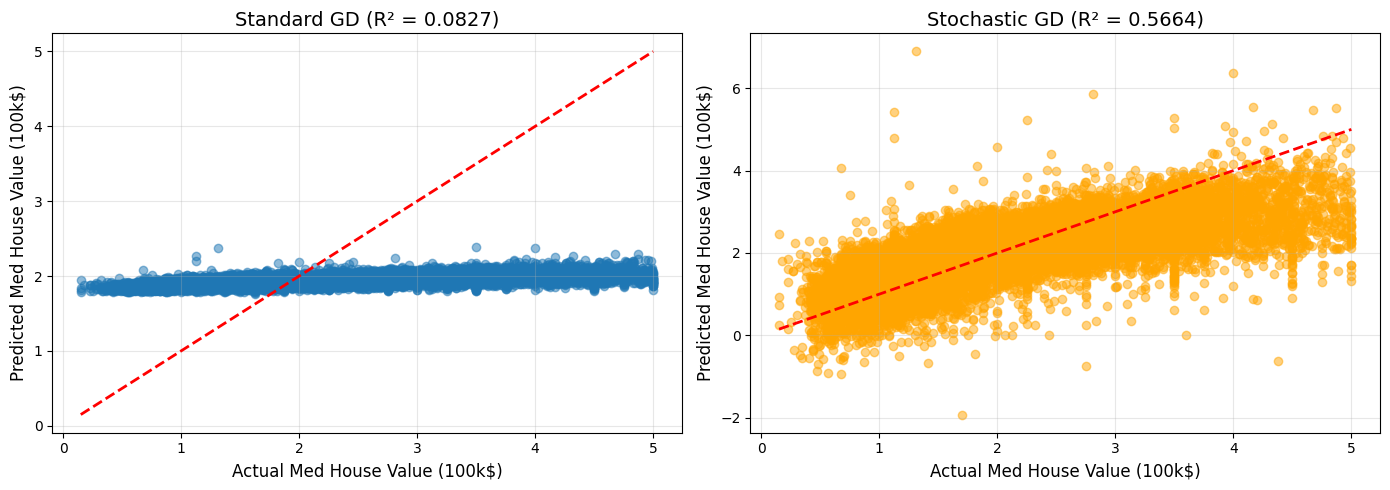

In [25]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_actual, y_pred_gd_decentered, alpha=0.5)
axes[0].plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Med House Value (100k$)', fontsize=12)
axes[0].set_ylabel('Predicted Med House Value (100k$)', fontsize=12)
axes[0].set_title(f'Standard GD (R² = {r2_center_gd:.4f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_actual, y_pred_sgd_decentered, alpha=0.5, color='orange')
axes[1].plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Med House Value (100k$)', fontsize=12)
axes[1].set_ylabel('Predicted Med House Value (100k$)', fontsize=12)
axes[1].set_title(f'Stochastic GD (R² = {r2_center_sgd:.4f})', fontsize=14)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()








#Problem 2: Assess the role of the step size in the performance of gradient descent


In [26]:
import time

#Step Sizes
step_sizes = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]

# Comparing Training time and Training dataset performance between Batch GD and Stochastic GD over varying step size

and storing each result into a list so as to plot their results

In [27]:
results = []
for step in step_sizes:
  print(f"\n#################  Step size (learning_rate) = {step}   #############################")

  ### Batch GD
  #Training time
  t0 = time.perf_counter()
  theta_gd, loss_gd = gradient_descent(X_normalized_with_bias, y_normalized,learning_rate=step, n_iterations=1000)
  t1 = time.perf_counter()
  time_diff_gd = t1 - t0
  print(f"\nTime taken (GD): {time_diff_gd:.2f} seconds")
  print(f"\nBias: {theta_gd[0, 0]:.4f}")
  print(f"\nFinal Loss (GD): {loss_gd[-1]:.6f}")

  #Training Dataset performance
  y_pred_gd_center = X_normalized_with_bias @ theta_gd
  y_pred_gd = y_pred_gd_center * y_std + y_mean

  ss_res = np.sum((y - y_pred_gd) ** 2)
  ss_tot = np.sum((y - np.mean(y)) ** 2)
  r2 = 1 - (ss_res / ss_tot)
  print(f"\nR² Score (Standard GD Centered Data): {r2:.4f}")
  rmse = np.sqrt(np.mean((y - y_pred_gd) ** 2))
  print(f"\nRMSE (Standard GD Centered Data): {rmse * 100000:.2f} in target units")


  ###  SGD
  # Training time
  t0 = time.perf_counter()
  theta_sgd, loss_sgd = stochastic_gradient_descent(X_normalized_with_bias, y_normalized,learning_rate=step, n_epochs=100)
  t1 = time.perf_counter()
  time_diff_sgd = t1 - t0

  print(f"\nTime taken (SGD): {time_diff_sgd:.2f} seconds")
  print(f"\nBias (SGD): {theta_sgd[0, 0]:.4f}")
  print(f"\nFinal Loss (SGD): {loss_sgd[-1]:.6f}")

  # Training Dataset performance
  y_pred_sgd_center = X_normalized_with_bias @ theta_sgd
  y_pred_sgd = y_pred_sgd_center * y_std + y_mean

  ss_res = np.sum((y - y_pred_sgd) ** 2)
  ss_tot = np.sum((y - np.mean(y)) ** 2)
  r2_sgd = 1 - (ss_res / ss_tot)
  rmse_sgd = np.sqrt(np.mean((y - y_pred_sgd) ** 2))

  print(f"\nR² Score (Stochastic GD Centered Data): {r2_sgd:.4f}")
  print(f"\nRMSE (Stochastic GD Centered Data): {rmse_sgd * 100000:.2f} in target units")
  print("\n##################################################################################\n")

  results.append({
        "step_size": step,
        "batch_time_sec": time_diff_gd,
        "batch_final_loss": float(loss_gd[-1]),
        "batch_r2": float(r2),
        "batch_rmse_100k": float(rmse),
        "batch_rmse_dollars": float(rmse * 100000),

        "sgd_time_sec": time_diff_sgd,
        "sgd_final_loss": float(loss_sgd[-1]),
        "sgd_r2": float(r2_sgd),
        "sgd_rmse_100k": float(rmse_sgd),
        "sgd_rmse_dollars": float(rmse_sgd * 100000),
    })
results_df = pd.DataFrame(results).sort_values("step_size").reset_index(drop=True)



#################  Step size (learning_rate) = 0.0001   #############################

Time taken (GD): 0.16 seconds

Bias: 0.0000

Final Loss (GD): 0.458635

R² Score (Standard GD Centered Data): 0.0827

RMSE (Standard GD Centered Data): 93580.06 in target units

Time taken (SGD): 12.05 seconds

Bias (SGD): -0.0001

Final Loss (SGD): 0.216813

R² Score (Stochastic GD Centered Data): 0.5664

RMSE (Stochastic GD Centered Data): 64341.64 in target units

##################################################################################


#################  Step size (learning_rate) = 0.0005   #############################

Time taken (GD): 0.15 seconds

Bias: -0.0000

Final Loss (GD): 0.356003

R² Score (Standard GD Centered Data): 0.2880

RMSE (Standard GD Centered Data): 82447.27 in target units

Time taken (SGD): 11.93 seconds

Bias (SGD): 0.0067

Final Loss (SGD): 0.251155

R² Score (Stochastic GD Centered Data): 0.4977

RMSE (Stochastic GD Centered Data): 69250.12 in target units



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-251/3074507971.py:9: RuntimeWarning: overflow encountered in square
  loss = (1 / (2 * m)) * np.sum(errors ** 2)
/tmp/ipython-input-251/96263973.py:20: RuntimeWarning: overflow encountered in matmul
  gradient = xi.T @ error
/tmp/ipython-input-251/96263973.py:22: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient
/tmp/ipython-input-251/96263973.py:18: RuntimeWarning: invalid value encountered in matmul
  prediction = xi @ theta



Time taken (SGD): 12.47 seconds

Bias (SGD): nan

Final Loss (SGD): nan

R² Score (Stochastic GD Centered Data): nan

RMSE (Stochastic GD Centered Data): nan in target units

##################################################################################


#################  Step size (learning_rate) = 0.01   #############################

Time taken (GD): 0.14 seconds

Bias: -0.0000

Final Loss (GD): 0.226929

R² Score (Standard GD Centered Data): 0.5461

RMSE (Standard GD Centered Data): 65825.60 in target units

Time taken (SGD): 12.08 seconds

Bias (SGD): nan

Final Loss (SGD): nan

R² Score (Stochastic GD Centered Data): nan

RMSE (Stochastic GD Centered Data): nan in target units

##################################################################################


#################  Step size (learning_rate) = 0.05   #############################

Time taken (GD): 0.13 seconds

Bias: -0.0000

Final Loss (GD): 0.215032

R² Score (Standard GD Centered Data): 0.5699

RMSE (Stand

# Graph Plotting
1. Training time vs Step size
2. RMSE vs Step size
3. R^2 vs Step size

 step_size  batch_time_sec  batch_final_loss  batch_r2  batch_rmse_100k  batch_rmse_dollars  sgd_time_sec  sgd_final_loss         sgd_r2  sgd_rmse_100k  sgd_rmse_dollars
    0.0001        0.158244          0.458635  0.082730         0.935801        93580.062446     12.045828    2.168128e-01   5.663744e-01   6.434164e-01      6.434164e+04
    0.0005        0.154776          0.356003  0.287995         0.824473        82447.270252     11.933395    2.511549e-01   4.976902e-01   6.925012e-01      6.925012e+04
    0.0010        0.127984          0.300321  0.399358         0.757256        75725.563305     13.218409   2.598282e+224 -5.196565e+224  2.227373e+112     2.227373e+117


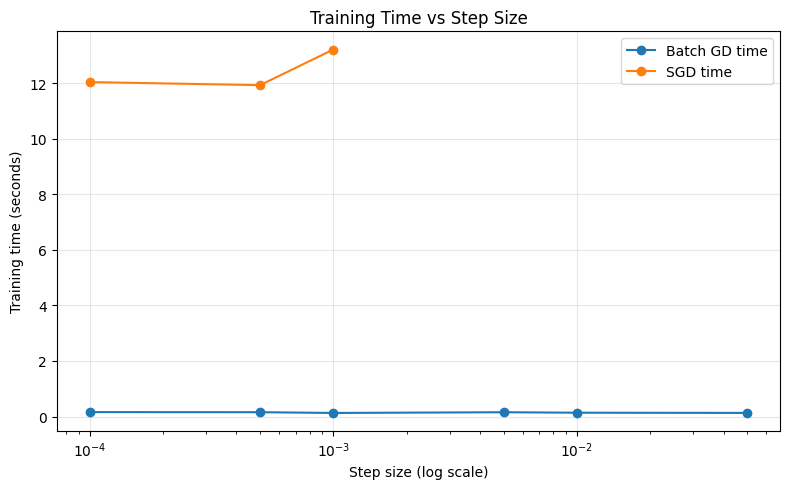

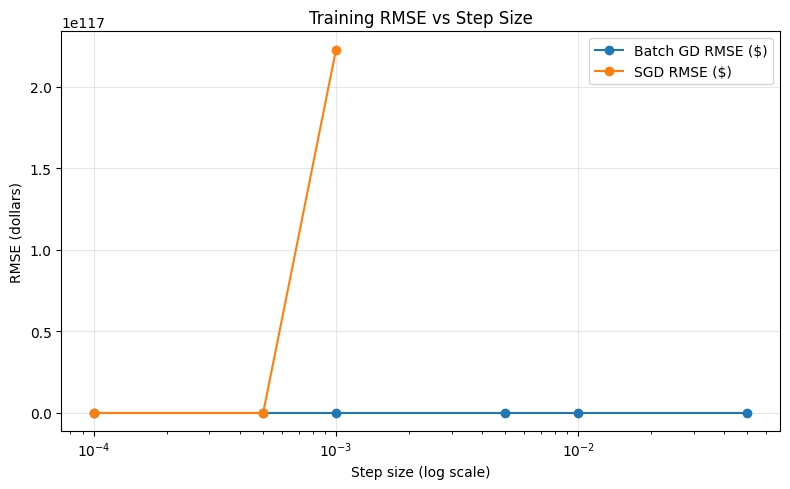

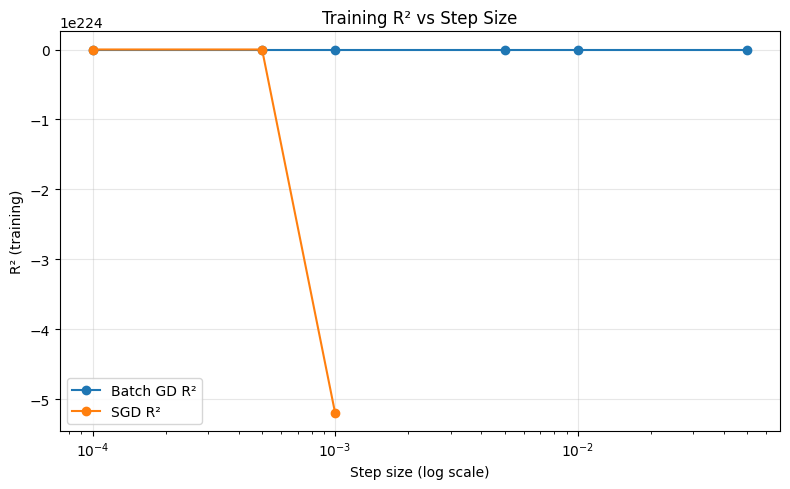

In [28]:
#print("\nSummary table (training set performance):")
results_df_sgd_clean = results_df.dropna(subset=["sgd_r2", "sgd_rmse_dollars", "sgd_time_sec"])
print(results_df_sgd_clean.to_string(index=False))

# Plot: runtime vs step size (Batch vs SGD)
plt.figure(figsize=(8, 5))
plt.plot(results_df["step_size"], results_df["batch_time_sec"], marker="o", label="Batch GD time")
plt.plot(results_df_sgd_clean["step_size"], results_df_sgd_clean["sgd_time_sec"], marker="o", label="SGD time")
plt.xscale("log")
plt.xlabel("Step size (log scale)")
plt.ylabel("Training time (seconds)")
plt.title("Training Time vs Step Size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: RMSE vs step size (Batch vs SGD)
plt.figure(figsize=(8, 5))
plt.plot(results_df["step_size"], results_df["batch_rmse_dollars"], marker="o", label="Batch GD RMSE ($)")
plt.plot(results_df_sgd_clean["step_size"], results_df_sgd_clean["sgd_rmse_dollars"], marker="o", label="SGD RMSE ($)")
plt.xscale("log")
plt.xlabel("Step size (log scale)")
plt.ylabel("RMSE (dollars)")
plt.title("Training RMSE vs Step Size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: R^2 vs step size (Batch vs SGD)
plt.figure(figsize=(8, 5))
plt.plot(results_df["step_size"], results_df["batch_r2"], marker="o", label="Batch GD R²")
plt.plot(results_df_sgd_clean["step_size"], results_df_sgd_clean["sgd_r2"], marker="o", label="SGD R²")
plt.xscale("log")
plt.xlabel("Step size (log scale)")
plt.ylabel("R² (training)")
plt.title("Training R² vs Step Size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Problem 3: Apply ridge regression using both batch and stochastic gradient descent

In [29]:
from sklearn.model_selection import KFold

#Taking the step size with best performance for GD and SGD from problem 2



In [37]:
best_lr_gd = 0.05
best_lr_sgd = 0.0001

lambda_values = [0, 0.1, 1, 10, 100, 1000]

# 5-fold cross validation
n_splits = 5
fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Compute Ridge loss and ridge gadient

In [31]:
def compute_ridge_loss(X, y, theta, lam):
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    data_loss = (1 / (2 * m)) * np.sum(errors ** 2)

    theta_no_bias = theta[1:, :]
    reg_loss = lam * np.sum(theta_no_bias ** 2)

    return data_loss + reg_loss


def compute_ridge_gradient(X, y, theta, lam):
    m = len(y)
    predictions = X @ theta
    errors = predictions - y

    grad = (1 / m) * (X.T @ errors)

    reg = np.zeros_like(theta)
    reg[1:, :] = 2 * lam * theta[1:, :]
    grad = grad + reg

    return grad


# Compute ridge Batch gradient descent

In [32]:
def ridge_gradient_descent(X, y, lam, learning_rate, n_iterations=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for i in range(n_iterations):
        gradient = compute_ridge_gradient(X, y, theta, lam)
        theta = theta - learning_rate * gradient

        loss = compute_ridge_loss(X, y, theta, lam)
        loss_history.append(loss)

    return theta, loss_history

# Compute Ridge Stochastic gradient descent

In [33]:
def ridge_stochastic_gradient_descent(X, y, lam, learning_rate=0.01, n_epochs=100, random_seed=42):
    np.random.seed(random_seed)
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(m)

        for i in indices:
            xi = X[i:i+1, :]
            yi = y[i:i+1, :]

            prediction = xi @ theta
            error = prediction - yi

            grad = xi.T @ error

            reg = np.zeros_like(theta)
            reg[1:, :] = 2 * lam * theta[1:, :]
            grad = grad + reg

            theta = theta - learning_rate * grad

        loss = compute_ridge_loss(X, y, theta, lam)
        loss_history.append(loss)

    return theta, loss_history

In [34]:
def evaluate_centered_model(X_norm_bias, y_true, theta, y_mean, y_std):
    y_pred_centered = X_norm_bias @ theta
    y_pred = y_pred_centered * y_std + y_mean

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return r2, rmse

#Compute Best Lambda for GD and SGD

Comparing training times and training dataset performance over different lamda's and computing the best lambda for GD and SGD

In [35]:
best_lam_gd = None
best_rmse_gd = np.inf

best_lam_sgd = None
best_rmse_sgd = np.inf

for lam in lambda_values:
    print(f"\n#################  Lambda = {lam}   #############################")
    gd_rmse_list = []
    sgd_rmse_list = []

    for fold_id, (train_id, val_id) in enumerate(fold.split(X_normalized_with_bias)):
        Xt, Xv = X_normalized_with_bias[train_id], X_normalized_with_bias[val_id]
        yt, yv = y_normalized[train_id], y_normalized[val_id]

        t0 = time.perf_counter()
        theta_gd, loss_gd = ridge_gradient_descent(Xt, yt, lam=lam, learning_rate=best_lr_gd, n_iterations=1000)
        t1 = time.perf_counter()
        time_diff_gd = t1 - t0


        t0 = time.perf_counter()
        theta_sgd, loss_sgd = ridge_stochastic_gradient_descent(Xt, yt, lam=lam, learning_rate=best_lr_sgd, n_epochs=100, random_seed=fold_id)
        t1 = time.perf_counter()
        time_diff_sgd = t1 - t0


        y_final = yv * y_std + y_mean

        r2_gd, rmse_gd = evaluate_centered_model(Xv, y_final, theta_gd, y_mean, y_std)

        r2_sgd, rmse_sgd = evaluate_centered_model(Xv, y_final, theta_sgd, y_mean, y_std)

        gd_rmse_list.append(rmse_gd)
        sgd_rmse_list.append(rmse_sgd)

    print(f"\nTime taken (GD): {time_diff_gd:.2f} seconds")
    print(f"\nBias: {theta_gd[0, 0]:.4f}")
    print(f"\nFinal Loss (GD): {loss_gd[-1]:.6f}")

    print(f"\nTime taken (SGD): {time_diff_sgd:.2f} seconds")
    print(f"\nBias (SGD): {theta_sgd[0, 0]:.4f}")
    print(f"\nFinal Loss (SGD): {loss_sgd[-1]:.6f}")

    print(f"\nR² Score (Standard GD Centered Data): {r2_gd:.4f}")
    print(f"\nRMSE (Standard GD Centered Data): {rmse_gd * 100000:.2f} in target units")

    print(f"\nR² Score (Stochastic GD Centered Data): {r2_sgd:.4f}")
    print(f"\nRMSE (Stochastic GD Centered Data): {rmse_sgd * 100000:.2f} in target units")

    print("\n##################################################################################\n")

    avg_rmse_gd = np.nanmean(gd_rmse_list)
    avg_rmse_sgd = np.nanmean(sgd_rmse_list)

    if avg_rmse_gd < best_rmse_gd:
        best_rmse_gd = avg_rmse_gd
        best_lam_gd = lam

    if avg_rmse_sgd < best_rmse_sgd:
        best_rmse_sgd = avg_rmse_sgd
        best_lam_sgd = lam


#################  Lambda = 0   #############################

Time taken (GD): 0.20 seconds

Bias: -0.0003

Final Loss (GD): 0.216445

Time taken (SGD): 17.34 seconds

Bias (SGD): -0.0030

Final Loss (SGD): 0.218997

R² Score (Standard GD Centered Data): 0.5810

RMSE (Standard GD Centered Data): 63239.07 in target units

R² Score (Stochastic GD Centered Data): 0.5761

RMSE (Stochastic GD Centered Data): 63607.25 in target units

##################################################################################


#################  Lambda = 0.1   #############################

Time taken (GD): 0.21 seconds

Bias: 0.0011

Final Loss (GD): 0.298066

Time taken (SGD): 16.21 seconds

Bias (SGD): -0.0010

Final Loss (SGD): 0.298211

R² Score (Standard GD Centered Data): 0.5035

RMSE (Standard GD Centered Data): 68839.55 in target units

R² Score (Stochastic GD Centered Data): 0.5037

RMSE (Stochastic GD Centered Data): 68828.00 in target units

#############################################

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-251/3968466866.py:5: RuntimeWarning: overflow encountered in square
  data_loss = (1 / (2 * m)) * np.sum(errors ** 2)
/tmp/ipython-input-251/3968466866.py:8: RuntimeWarning: overflow encountered in scalar multiply
  reg_loss = lam * np.sum(theta_no_bias ** 2)
/tmp/ipython-input-251/3968466866.py:8: RuntimeWarning: overflow encountered in square
  reg_loss = lam * np.sum(theta_no_bias ** 2)
/tmp/ipython-input-251/3968466866.py:18: RuntimeWarning: overflow encountered in matmul
  grad = (1 / m) * (X.T @ errors)
/tmp/ipython-input-251/3968466866.py:3: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ theta
/tmp/ipython-input-251/3968466866.py:15: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ theta
/tmp/ipython-input-251/3968466866.py:18: RuntimeWarn


Time taken (GD): 0.19 seconds

Bias: nan

Final Loss (GD): nan

Time taken (SGD): 17.31 seconds

Bias (SGD): 0.0024

Final Loss (SGD): 0.499016

R² Score (Standard GD Centered Data): nan

RMSE (Standard GD Centered Data): nan in target units

R² Score (Stochastic GD Centered Data): 0.0045

RMSE (Stochastic GD Centered Data): 97475.34 in target units

##################################################################################


#################  Lambda = 1000   #############################


/tmp/ipython-input-251/234889928.py:53: RuntimeWarning: Mean of empty slice
  avg_rmse_gd = np.nanmean(gd_rmse_list)
/tmp/ipython-input-251/3968466866.py:21: RuntimeWarning: overflow encountered in multiply
  reg[1:, :] = 2 * lam * theta[1:, :]



Time taken (GD): 0.21 seconds

Bias: nan

Final Loss (GD): nan

Time taken (SGD): 16.74 seconds

Bias (SGD): 0.0024

Final Loss (SGD): 0.500034

R² Score (Standard GD Centered Data): nan

RMSE (Standard GD Centered Data): nan in target units

R² Score (Stochastic GD Centered Data): 0.0000

RMSE (Stochastic GD Centered Data): 97695.86 in target units

##################################################################################



# Below output shows the best lambda for Batch GD and Stochastic GD

In [36]:
print("Best lambda (Batch GD):", best_lam_gd, "Avg RMSE:", best_rmse_gd * 100000)
print("Best lambda (SGD):", best_lam_sgd, "Avg RMSE:", best_rmse_sgd * 100000)

Best lambda (Batch GD): 0 Avg RMSE: 64411.389644727424
Best lambda (SGD): 0 Avg RMSE: 64553.25381979595
